In [1]:
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel, AdamW, get_cosine_schedule_with_warmup
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def remove_lines(text: str) -> str:
    cleaned_lines = []
    photo_pattern = re.compile(r'\bФото(?:\s+\S+)*?\s*/\s*\S+', flags=re.IGNORECASE)
    for line in text.splitlines():
        stripped = line.strip()
        if not stripped:
            continue
        if stripped == "Низкие комиссии. Ежедневная подборка инвестиционных идей":
            continue
        if re.fullmatch(r"[\-,]+", stripped):
            continue

        # удаляем все вхождения 'Фото .../...'
        line = photo_pattern.sub('', line)

        cleaned_lines.append(line)
    return "\n".join(cleaned_lines)

In [3]:
# MODEL_NAME = "mxlcw/rubert-tiny2-russian-financial-sentiment"
MODEL_NAME = "DeepPavlov/rubert-base-cased"
MAX_LEN = 256
FREEZE_LAYERS = 3

In [4]:
class FusionDataset(Dataset):
    def __init__(self, csv_path: str):
        df = pd.read_csv(csv_path)
        df["title"].fillna("", inplace=True)
        df["text"].fillna("", inplace=True)

        self.tok = AutoTokenizer.from_pretrained(MODEL_NAME)
        self.samples = []
        for _, row in df.iterrows():
            txt = f"{row['title']} {row['text']}".strip()
            enc = self.tok(txt, truncation=True, padding="max_length",
                           max_length=MAX_LEN, return_tensors="pt")
            self.samples.append((
                enc["input_ids"].squeeze(0),
                enc["attention_mask"].squeeze(0),
                torch.tensor(int(row["label"]), dtype=torch.long)
            ))

        self.label_counts = np.bincount([lbl.item() for *_, lbl in self.samples])
        print(f"Dataset size: {len(self)} | class 0/1 = {self.label_counts}")

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

In [5]:
class FusionModel(nn.Module):
    def __init__(self, dropout: float = 0.5):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)

        for name, p in self.bert.named_parameters():
            if "encoder.layer." in name:
                layer = int(name.split(".")[2])
                if layer < FREEZE_LAYERS:
                    p.requires_grad = False

        hid = self.bert.config.hidden_size
        self.mlp = nn.Sequential(
            nn.Linear(hid, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.LayerNorm(256),
            nn.Linear(256, 2),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        pooled = out.pooler_output 
        return self.mlp(pooled)   

In [6]:
def run_epoch(model, loader, optimizer, train: bool):
    model.train() if train else model.eval()
    total_loss, steps = 0.0, 0
    logits_list, labels_list = [], []

    for input_ids, attn_mask, labels in tqdm(loader, desc="Train" if train else "Val", leave=False):
        input_ids, attn_mask, labels = (
            input_ids.to(dev), attn_mask.to(dev), labels.to(dev)
        )
        with torch.set_grad_enabled(train):
            logits = model(input_ids, attn_mask)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item()
        steps += 1
        logits_list.append(logits.detach().cpu())
        labels_list.extend(labels.cpu().tolist())


    all_logits = torch.cat(logits_list)
    probas_pos = torch.softmax(all_logits, 1)[:,1].numpy()
    y_true     = np.array(labels_list)
    thr = 0.5
    y_pred = probas_pos >= thr

    metrics = {
        "loss": total_loss/steps,
        "thr":  thr,
        "acc":  accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec":  recall_score(y_true, y_pred, zero_division=0),
        "f1":   f1_score(y_true, y_pred, zero_division=0),
    }

    if not train:
        metrics["roc_auc"] = roc_auc_score(y_true, probas_pos)
        metrics["pr_auc"]  = average_precision_score(y_true, probas_pos)

    return metrics

In [7]:
dataset = FusionDataset("fusion_dataset.csv")
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_ds, val_ds = random_split(dataset, [int(0.8*len(dataset)), len(dataset) - int(0.8*len(dataset))])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

# взвешенный лосс
class_weights = torch.tensor(
    [len(dataset)/(2*c) for c in dataset.label_counts],
    dtype=torch.float, device=dev
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

c:\Users\andrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Dataset size: 17437 | class 0/1 = [9919 7518]


In [8]:
model = FusionModel().to(dev)
no_decay = ["bias", "LayerNorm.weight"]
opt_groups = [
    {
        "params":[p for n,p in model.named_parameters() if p.requires_grad and not any(nd in n for nd in no_decay)],
        "weight_decay": 1e-2
    },
    {
        "params":[p for n,p in model.named_parameters() if p.requires_grad and any(nd in n for nd in no_decay)],
        "weight_decay": 0.0
    },
]
optimizer = AdamW(opt_groups, lr=2e-5)
total_steps = len(train_loader) * 15
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1*total_steps),
    num_training_steps=total_steps,
    last_epoch=-1
)

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
c:\Users\andrey\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\optimization.py:521: Futu

In [9]:
best_val_loss, patience, stale = float("inf"), 2, 0
for epoch in tqdm(range(1, 31)):
    train_metrics = run_epoch(model, train_loader, optimizer, train=True)
    scheduler.step()
    val_metrics   = run_epoch(model, val_loader, optimizer, train=False)

    if val_metrics["loss"] + 1e-4 < best_val_loss:
        best_val_loss = val_metrics["loss"]
        stale = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        stale += 1
        if stale > patience:
            print("Early stopping triggered.")
            break

print(f"[Train] loss={train_metrics['loss']:.4f} "
        f"acc={train_metrics['acc']:.3f} f1={train_metrics['f1']:.3f}")
print(f"[ Val ] loss={val_metrics['loss']:.4f} "
        f"acc={val_metrics['acc']:.3f} f1={val_metrics['f1']:.3f} "
        f"ROC-AUC={val_metrics['roc_auc']:.3f} PR-AUC={val_metrics['pr_auc']:.3f}")
print("Training complete. Best model saved to 'best_model.pt'.")

  0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/436 [00:00<?, ?it/s]

Val:   0%|          | 0/109 [00:00<?, ?it/s]

Train:   0%|          | 0/436 [00:00<?, ?it/s]

Val:   0%|          | 0/109 [00:00<?, ?it/s]

...

Train:   0%|          | 0/436 [00:00<?, ?it/s]

Val:   0%|          | 0/109 [00:00<?, ?it/s]

Train:   0%|          | 0/436 [00:00<?, ?it/s]

Val:   0%|          | 0/109 [00:00<?, ?it/s]

Early stopping triggered.
[Train] loss=0.6253 acc=0.645 f1=0.614
[ Val ] loss=0.6379 acc=0.659 f1=0.632 ROC-AUC=0.713 PR-AUC=0.637
Training complete. Best model saved to 'best_model.pt'.


In [12]:
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for input_ids, attn_mask, labels in val_loader:
        out = model(input_ids.to(dev), attn_mask.to(dev))
        all_logits.append(out.cpu())
        all_labels.extend(labels.tolist())

all_logits = torch.cat(all_logits)
probas_pos = torch.softmax(all_logits, 1)[:,1].numpy()
y_true     = np.array(all_labels)
thrs = np.arange(0.0, 1.0, 0.001)
f1s  = [f1_score(y_true, probas_pos>=t) for t in thrs]
best_thr = thrs[int(np.argmax(f1s))]
print(f"Best threshold on val set for F1: {best_thr:.3f}")

Best threshold on val set for F1: 0.318


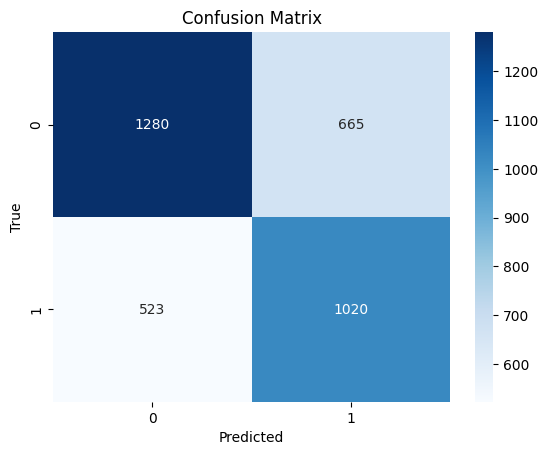

In [15]:
y_pred = probas_pos >= 0.5
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()